<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/GLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import torch
import gc
import joblib
import os

from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from model_utils import build_features_920, standardize, apg_huber_enet_gpu

from google.colab import drive
import warnings
warnings.filterwarnings('ignore')


In [34]:
# ============================================================
# 0. basic config
# ============================================================
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [35]:
# ============================================================
# 1. spline basis
# ============================================================

@dataclass
class SplineSpec:
    feature_names: List[str]
    n_knots: int = 3
    include_linear: bool = True
    quantile_low: float = 0.05
    quantile_high: float = 0.95


def compute_knots_from_train(
    x_train: np.ndarray,
    n_knots: int,
    q_low: float = 0.05,
    q_high: float = 0.95,
) -> np.ndarray:
    """
    Compute knot locations from TRAINING data only.
    """
    if n_knots <= 0:
        return np.array([], dtype=float)

    qs = np.linspace(q_low, q_high, n_knots + 2)[1:-1]
    knots = np.quantile(x_train[~np.isnan(x_train)], qs)
    return np.asarray(knots, dtype=float)


def truncated_quadratic_basis(
    x: np.ndarray,
    knots: np.ndarray,
    include_linear: bool = True,
) -> np.ndarray:
    """
    Basis for one feature:
        [x, (x-c1)_+^2, ..., (x-cm)_+^2]
    or only hinge terms if include_linear=False
    """
    cols = []

    if include_linear:
        cols.append(x.reshape(-1, 1))

    for c in knots:
        cols.append(np.maximum(x - c, 0.0).reshape(-1, 1) ** 2)

    if len(cols) == 0:
        raise ValueError("Basis is empty. Need include_linear=True or n_knots>0.")

    return np.concatenate(cols, axis=1)



In [36]:

# ============================================================
# 2. build GLM design matrix + group structure
# ============================================================

@dataclass
class GLMDesign:
    X: torch.Tensor               # no intercept inside; intercept handled separately
    y: torch.Tensor
    group_slices: List[slice]     # one slice per raw feature
    knot_dict: Dict[str, np.ndarray]
    scaler_mean: Dict[str, float]
    scaler_std: Dict[str, float]
    feature_names: List[str]


def fit_feature_scaler(x_train: np.ndarray) -> Tuple[float, float]:
    mu = np.nanmean(x_train)
    sd = np.nanstd(x_train)
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    return float(mu), float(sd)


def apply_feature_scaler(x: np.ndarray, mu: float, sd: float) -> np.ndarray:
    return (x - mu) / sd


def build_glm_design_train(
    df_train: pd.DataFrame,
    y_col: str,
    spec: SplineSpec,
    device: Optional[torch.device] = None,
) -> GLMDesign:
    """
    Fit scaling + knots using training sample only, and build training design matrix.
    """
    if device is None:
        device = get_device()

    X_blocks = []
    group_slices = []
    knot_dict = {}
    scaler_mean = {}
    scaler_std = {}

    col_start = 0

    for feat in spec.feature_names:
        x_raw = df_train[feat].to_numpy(dtype=float)

        mu, sd = fit_feature_scaler(x_raw)
        x_std = apply_feature_scaler(x_raw, mu, sd)

        knots = compute_knots_from_train(
            x_train=x_std,
            n_knots=spec.n_knots,
            q_low=spec.quantile_low,
            q_high=spec.quantile_high,
        )

        block = truncated_quadratic_basis(
            x=x_std,
            knots=knots,
            include_linear=spec.include_linear,
        )

        k = block.shape[1]
        group_slices.append(slice(col_start, col_start + k))
        col_start += k

        X_blocks.append(block)
        knot_dict[feat] = knots
        scaler_mean[feat] = mu
        scaler_std[feat] = sd

    X_np = np.concatenate(X_blocks, axis=1)
    y_np = df_train[y_col].to_numpy(dtype=float).reshape(-1)

    # optional: drop rows with nan in y or X
    valid = np.isfinite(y_np) & np.all(np.isfinite(X_np), axis=1)
    X_np = X_np[valid]
    y_np = y_np[valid]

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)

    return GLMDesign(
        X=X,
        y=y,
        group_slices=group_slices,
        knot_dict=knot_dict,
        scaler_mean=scaler_mean,
        scaler_std=scaler_std,
        feature_names=spec.feature_names,
    )


def build_glm_design_apply(
    df: pd.DataFrame,
    y_col: str,
    fitted_design: GLMDesign,
    spec: SplineSpec,
    device: Optional[torch.device] = None,
) -> GLMDesign:
    """
    Use training-fitted scaler + knots to build validation/test design matrix.
    """
    if device is None:
        device = get_device()

    X_blocks = []

    for feat in spec.feature_names:
        x_raw = df[feat].to_numpy(dtype=float)

        mu = fitted_design.scaler_mean[feat]
        sd = fitted_design.scaler_std[feat]
        knots = fitted_design.knot_dict[feat]

        x_std = apply_feature_scaler(x_raw, mu, sd)

        block = truncated_quadratic_basis(
            x=x_std,
            knots=knots,
            include_linear=spec.include_linear,
        )
        X_blocks.append(block)

    X_np = np.concatenate(X_blocks, axis=1)
    y_np = df[y_col].to_numpy(dtype=float).reshape(-1)

    valid = np.isfinite(y_np) & np.all(np.isfinite(X_np), axis=1)
    X_np = X_np[valid]
    y_np = y_np[valid]

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)

    return GLMDesign(
        X=X,
        y=y,
        group_slices=fitted_design.group_slices,
        knot_dict=fitted_design.knot_dict,
        scaler_mean=fitted_design.scaler_mean,
        scaler_std=fitted_design.scaler_std,
        feature_names=fitted_design.feature_names,
    )

def build_glm_design_train_from_matrix(
    X_raw: np.ndarray,
    y_raw: np.ndarray,
    feature_names: List[str],
    spec: SplineSpec,
    n_linear_features: int = 0,
    device: Optional[torch.device] = None,
) -> GLMDesign:
    if device is None:
        device = get_device()

    X_blocks = []
    group_slices = []
    knot_dict = {}
    scaler_mean = {}
    scaler_std = {}

    col_start = 0

    for j, feat in enumerate(feature_names):

        if j >= len(feature_names) - n_linear_features:
          x_raw = X_raw[:, j].astype(np.float32, copy=False)
          knots = compute_knots_from_train(
              x_train=x_raw,
              n_knots=0,
              q_low=spec.quantile_low,
              q_high=spec.quantile_high,
          )

          block = truncated_quadratic_basis(
              x=x_raw,
              knots=knots,
              include_linear=True,
          ).astype(np.float32, copy=False)

          mu, sd = 0.0, 1.0

        else:
          x_raw = X_raw[:, j].astype(np.float32, copy=False)

          mu, sd = fit_feature_scaler(x_raw)
          x_std = apply_feature_scaler(x_raw, mu, sd)

          knots = compute_knots_from_train(
              x_train=x_std,
              n_knots=spec.n_knots,
              q_low=spec.quantile_low,
              q_high=spec.quantile_high,
          )

          block = truncated_quadratic_basis(
              x=x_std,
              knots=knots,
              include_linear=spec.include_linear,
          ).astype(np.float32, copy=False)

        k = block.shape[1]
        group_slices.append(slice(col_start, col_start + k))
        col_start += k

        X_blocks.append(block)
        knot_dict[feat] = knots
        scaler_mean[feat] = mu
        scaler_std[feat] = sd

    X_np = np.concatenate(X_blocks, axis=1).astype(np.float32, copy=False)
    y_np = y_raw.astype(np.float32, copy=False).reshape(-1)

    valid = np.isfinite(y_np) & np.all(np.isfinite(X_np), axis=1)
    X_np = X_np[valid]
    y_np = y_np[valid]

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)

    return GLMDesign(
        X=X,
        y=y,
        group_slices=group_slices,
        knot_dict=knot_dict,
        scaler_mean=scaler_mean,
        scaler_std=scaler_std,
        feature_names=feature_names,
    )


def build_glm_design_apply_from_matrix(
    X_raw: np.ndarray,
    y_raw: np.ndarray,
    fitted_design: GLMDesign,
    spec: SplineSpec,
    n_linear_features: int = 0,
    device: Optional[torch.device] = None,
) -> GLMDesign:
    if device is None:
        device = get_device()

    X_blocks = []

    for j, feat in enumerate(fitted_design.feature_names):
        x_raw = X_raw[:, j].astype(np.float32, copy=False)

        if j >= len(fitted_design.feature_names) - n_linear_features:

          block = truncated_quadratic_basis(
            x=x_raw,
            knots=np.array([]),
            include_linear=True,
        ).astype(np.float32, copy=False)

        else:
          mu = fitted_design.scaler_mean[feat]
          sd = fitted_design.scaler_std[feat]
          knots = fitted_design.knot_dict[feat]

          x_std = apply_feature_scaler(x_raw, mu, sd)

          block = truncated_quadratic_basis(
              x=x_std,
              knots=knots,
              include_linear=spec.include_linear,
          ).astype(np.float32, copy=False)

        X_blocks.append(block)

    X_np = np.concatenate(X_blocks, axis=1).astype(np.float32, copy=False)
    y_np = y_raw.astype(np.float32, copy=False).reshape(-1)

    valid = np.isfinite(y_np) & np.all(np.isfinite(X_np), axis=1)
    X_np = X_np[valid]
    y_np = y_np[valid]

    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)

    return GLMDesign(
        X=X,
        y=y,
        group_slices=fitted_design.group_slices,
        knot_dict=fitted_design.knot_dict,
        scaler_mean=fitted_design.scaler_mean,
        scaler_std=fitted_design.scaler_std,
        feature_names=fitted_design.feature_names,
    )


In [37]:

# ============================================================
# 3. loss and gradient
# ============================================================

def predict_glm(X: torch.Tensor, beta: torch.Tensor, intercept: torch.Tensor) -> torch.Tensor:
    return intercept + X @ beta


def l2_loss_and_grad(
    X: torch.Tensor,
    y: torch.Tensor,
    beta: torch.Tensor,
    intercept: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns:
        loss, grad_beta, grad_intercept
    loss = mean((y - yhat)^2)
    """
    yhat = predict_glm(X, beta, intercept)
    resid = y - yhat
    n = y.shape[0]

    loss = torch.mean(resid ** 2)

    grad_beta = -(2.0 / n) * (X.T @ resid)
    grad_intercept = -(2.0 / n) * torch.sum(resid)

    return loss, grad_beta, grad_intercept


def huber_loss_and_grad(
    X: torch.Tensor,
    y: torch.Tensor,
    beta: torch.Tensor,
    intercept: torch.Tensor,
    xi: float,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Huber loss:
        x^2                     if |x| <= xi
        2*xi*|x| - xi^2         if |x| > xi
    """
    yhat = predict_glm(X, beta, intercept)
    resid = y - yhat
    abs_r = torch.abs(resid)
    n = y.shape[0]

    quad_mask = abs_r <= xi
    loss_vec = torch.where(
        quad_mask,
        resid ** 2,
        2.0 * xi * abs_r - xi ** 2
    )
    loss = torch.mean(loss_vec)

    psi = torch.where(
        quad_mask,
        2.0 * resid,
        2.0 * xi * torch.sign(resid)
    )

    grad_beta = -(1.0 / n) * (X.T @ psi)
    grad_intercept = -(1.0 / n) * torch.sum(psi)

    return loss, grad_beta, grad_intercept



In [38]:
# ============================================================
# 4. group lasso prox
# ============================================================

# def prox_group_lasso(
#     v: torch.Tensor,
#     step_size: float,
#     lam: float,
#     group_slices: List[slice],
# ) -> torch.Tensor:
#     """
#     Group lasso prox:
#         prox(v_g) = (1 - step*lam / ||v_g||)_+ * v_g
#     """
#     out = v.clone()

#     for g in group_slices:
#         block = out[g]
#         norm = torch.norm(block, p=2)

#         thresh = step_size * lam
#         if norm <= thresh:
#             out[g] = 0.0
#         else:
#             shrink = 1.0 - thresh / norm
#             out[g] = shrink * block

#     return out

def prox_group_lasso(
    v: torch.Tensor,
    step_size: float,
    lam: float,
    n_spline_groups: int = 846,
    n_linear_groups: int = 74,
    n_knots: int = 3,
) -> torch.Tensor:
    """
    向量化优化的 Group Lasso Prox:
    - 前 846 个 groups (size=4) 采用矩阵化 Norm 计算
    - 后 74 个 groups (size=1) 采用向量化 Soft-thresholding
    """
    out = torch.zeros_like(v)
    thresh = step_size * lam

    # 索引界限定义
    spline_end = n_spline_groups * (n_knots + 1)

    # --- 第一段：Spline Groups (Size=4) ---
    v_spline = v[:spline_end].reshape(n_spline_groups, n_knots + 1)
    # 计算每一行的 L2 norm (846, 1)
    norms = torch.norm(v_spline, p=2, dim=1, keepdim=True)

    # 计算收缩因子，并处理 norm=0 的情况（防止除以0）
    # 使用 torch.clamp 将 (1 - thresh/norm) 小于 0 的部分截断为 0
    shrinkage = torch.clamp(1.0 - thresh / torch.clamp(norms, min=1e-12), min=0.0)

    # Broadcasting 作用于每一行并展平
    out[:spline_end] = (v_spline * shrinkage).flatten()

    # --- 第二段：Linear Groups (Size=1) ---
    v_linear = v[spline_end : spline_end + n_linear_groups]

    # 标准 Soft-thresholding: sign(x) * max(|x| - thresh, 0)
    out[spline_end : spline_end + n_linear_groups] = torch.sign(v_linear) * torch.clamp(torch.abs(v_linear) - thresh, min=0.0)

    return out

In [39]:
# ============================================================
# 5. objective
# ============================================================

# def group_lasso_penalty(beta: torch.Tensor, lam: float, group_slices: List[slice]) -> torch.Tensor:
#     pen = torch.zeros(1, dtype=beta.dtype, device=beta.device)
#     for g in group_slices:
#         pen = pen + lam * torch.norm(beta[g], p=2)
#     return pen.squeeze()

def group_lasso_penalty(
    beta: torch.Tensor,
    lam: float,
    n_spline_groups: int = 846,
    n_linear_groups: int = 74,
    n_knots: int = 3,
) -> torch.Tensor:
    """
    向量化优化的 Group Lasso 惩罚项计算：
    - 前 846 个 groups (size=4) 采用矩阵化 Norm 求和
    - 后 74 个 groups (size=1) 采用向量化绝对值求和
    """
    spline_end = n_spline_groups * (n_knots + 1) # 3384

    # --- 第一段：Spline Groups (Size=4) ---
    # reshape 为 (846, 4)，在 dim=1 上计算 L2 norm，得到 (846,)，然后求和
    v_spline = beta[:spline_end].reshape(n_spline_groups, n_knots + 1)
    norm_sum_spline = torch.norm(v_spline, p=2, dim=1).sum()

    # --- 第二段：Linear Groups (Size=1) ---
    # size=1 的组，L2 norm 等于绝对值
    v_linear = beta[spline_end : spline_end + n_linear_groups]
    norm_sum_linear = torch.abs(v_linear).sum()

    # 两段求和后乘以 lambda
    total_penalty = lam * (norm_sum_spline + norm_sum_linear)

    return total_penalty

def objective_value(
    X: torch.Tensor,
    y: torch.Tensor,
    beta: torch.Tensor,
    intercept: torch.Tensor,
    lam: float,
    group_slices: List[slice],
    loss_type: str = "l2",
    xi: Optional[float] = None,
    n_spline_groups: int = 846,
    n_linear_groups: int = 74,
    n_knots: int = 3,
) -> torch.Tensor:
    if loss_type == "l2":
        loss, _, _ = l2_loss_and_grad(X, y, beta, intercept)
    elif loss_type == "huber":
        if xi is None:
            raise ValueError("xi must be provided for huber loss.")
        loss, _, _ = huber_loss_and_grad(X, y, beta, intercept, xi)
    else:
        raise ValueError(f"Unknown loss_type={loss_type}")

    pen = group_lasso_penalty(beta, lam, n_spline_groups, n_linear_groups, n_knots) #, group_slices)
    return loss + pen


In [40]:

# ============================================================
# 6. APG solver
# ============================================================

@dataclass
class APGResult:
    beta: torch.Tensor
    intercept: torch.Tensor
    obj_path: List[float]
    converged: bool
    n_iter: int


def apg_group_lasso(
    X: torch.Tensor,
    y: torch.Tensor,
    group_slices: List[slice],
    lam: float,
    loss_type: str = "l2",
    xi: Optional[float] = None,
    max_iter: int = 500,
    tol: float = 1e-6,
    step_size: float = 1e-1,
    backtracking: bool = True,
    restart: bool = True,
    beta_init: Optional[torch.Tensor] = None,
    intercept_init: Optional[torch.Tensor] = None,
    verbose: bool = False,
    n_spline_groups: int = 846,
    n_linear_groups: int = 74,
    n_knots: int = 3,
) -> APGResult:
    """
    First-version APG solver for:
        min loss(beta, intercept) + lam * sum_g ||beta_g||_2
    """
    p = X.shape[1]
    device = X.device
    dtype = X.dtype

    beta = torch.zeros(p, dtype=dtype, device=device) if beta_init is None else beta_init.clone()
    intercept = torch.zeros(1, dtype=dtype, device=device).squeeze() if intercept_init is None else intercept_init.clone()

    theta_beta = beta.clone()
    theta_intercept = intercept.clone()

    # t_k = 1.0
    obj_path = []

    prev_obj = objective_value(
        X, y, beta, intercept, lam, group_slices, loss_type=loss_type, xi=xi, n_spline_groups=n_spline_groups, n_linear_groups=n_linear_groups, n_knots=n_knots
    ).item()
    obj_path.append(prev_obj)

    converged = False
    patience = 0

    for it in range(1, max_iter + 1):
        # gradient at extrapolated point
        if loss_type == "l2":
            loss_val, grad_beta, grad_intercept = l2_loss_and_grad(
                X, y, theta_beta, theta_intercept
            )
        elif loss_type == "huber":
            loss_val, grad_beta, grad_intercept = huber_loss_and_grad(
                X, y, theta_beta, theta_intercept, xi
            )
        else:
            raise ValueError(f"Unknown loss_type={loss_type}")

        step = step_size

        while True:
            beta_new = prox_group_lasso(
                theta_beta - step * grad_beta,
                step_size=step,
                lam=lam,
                n_spline_groups=n_spline_groups ,
                n_linear_groups=n_linear_groups ,
                n_knots=n_knots,
            )
            intercept_new = theta_intercept - step * grad_intercept

            obj_new = objective_value(
                X, y, beta_new, intercept_new, lam, group_slices,
                loss_type=loss_type, xi=xi,
                n_spline_groups=n_spline_groups , n_linear_groups=n_linear_groups,
                n_knots=n_knots,
            )

            if (not backtracking) or (obj_new.item() <= prev_obj + 1e-12):
                break

            step *= 0.5
            if step < 1e-10:
                break

        # Nesterov update
        # t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t_k ** 2))
        momentum = it / (it+3.0) # (t_k - 1.0) / t_new

        theta_beta_new = beta_new + momentum * (beta_new - beta)
        theta_intercept_new = intercept_new + momentum * (intercept_new - intercept)

        # adaptive restart
        if restart:
            diff_beta = beta_new - beta
            diff_theta = theta_beta_new - beta_new
            if torch.dot(diff_beta, diff_theta) > 0:
                # t_new = 1.0
                theta_beta_new = beta_new.clone()
                theta_intercept_new = intercept_new.clone()

        # convergence
        rel_change = torch.norm(beta_new - beta) / (torch.norm(beta) + 1e-8)

        beta = beta_new
        intercept = intercept_new
        theta_beta = theta_beta_new
        theta_intercept = theta_intercept_new
        # t_k = t_new

        current_obj = obj_new.item()
        obj_path.append(current_obj)

        if verbose and (it % 20 == 0 or it == 1):
            print(f"iter={it:4d} obj={current_obj:.8f} rel_change={rel_change.item():.3e} step={step:.2e}")

        if rel_change.item() < tol or abs(prev_obj - current_obj) / (abs(prev_obj) + 1e-8) < tol:
            converged = True
            break

        if current_obj < prev_obj:
            patience = 0
        else:
            patience += 1

        prev_obj = current_obj

        if patience >= 20:
            break

    return APGResult(
        beta=beta,
        intercept=intercept,
        obj_path=obj_path,
        converged=converged,
        n_iter=it,
    )

In [41]:

# ============================================================
# 7. validation scoring
# ============================================================

def mse_score(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    return torch.mean((y_true - y_pred) ** 2).item()


def huber_score(y_true: torch.Tensor, y_pred: torch.Tensor, xi: float) -> float:
    resid = y_true - y_pred
    abs_r = torch.abs(resid)
    loss = torch.where(abs_r <= xi, resid**2, 2.0 * xi * abs_r - xi**2)
    return torch.mean(loss).item()


def oos_r2(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum(y_true ** 2)   # paper uses no demeaning
    return (1.0 - ss_res / ss_tot).item()


In [42]:


# ============================================================
# 8. simple tuning wrapper
# ============================================================

def tune_glm_group_lasso(
    train_design: GLMDesign,
    valid_design: GLMDesign,
    lambda_grid: List[float],
    loss_type: str = "l2",
    xi: Optional[float] = None,
    max_iter: int = 500,
    tol: float = 1e-6,
    verbose: bool = False,
    n_spline_groups: int = 846,
    n_linear_groups: int = 74,
    n_knots: int = 3,
):
    best = None
    beta_warm = None
    intercept_warm = None

    for lam in sorted(lambda_grid, reverse=True):  # large -> small for warm start
        res = apg_group_lasso(
            X=train_design.X,
            y=train_design.y,
            group_slices=train_design.group_slices,
            lam=lam,
            loss_type=loss_type,
            xi=xi,
            max_iter=max_iter,
            tol=tol,
            beta_init=beta_warm,
            intercept_init=intercept_warm,
            verbose=verbose,
            n_spline_groups=n_spline_groups ,
            n_linear_groups=n_linear_groups,
            n_knots=n_knots,
        )

        yhat_valid = predict_glm(valid_design.X, res.beta, res.intercept)

        if loss_type == "l2":
            val_score = mse_score(valid_design.y, yhat_valid)
        else:
            val_score = huber_score(valid_design.y, yhat_valid, xi)

        record = {
            "lambda": lam,
            "val_score": val_score,
            "result": res,
        }

        if best is None or val_score < best["val_score"]:
            best = record

        beta_warm = res.beta.detach().clone()
        intercept_warm = res.intercept.detach().clone()

    return best

In [43]:
@dataclass
class GLMConfig:
    # data / columns
    y_col: str = "exret_lead1"
    date_col: str = "DATE"
    feature_names: List[str] = field(default_factory=list)
    n_linear_features: int = 0

    # spline
    n_knots: int = 3

    # penalty / loss
    lambda_grid: List[float] = field(default_factory=lambda: list(np.logspace(-4, -1, 9)))
    loss_type: str = "l2"
    xi: Optional[float] = None

    # optimization
    max_iter: int = 1000
    tol: float = 1e-5

    # time split
    valid_span: int = 12
    min_train_years: int = 10

    # runtime / output
    verbose: bool = True
    keep_details: bool = True

In [44]:
# ── GPU Setup ────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    DEVICE = torch.device('cpu')
    print('WARNING: No GPU found — falling back to CPU (will be slow!)')
    print('  → Go to Runtime → Change runtime type → T4 GPU → Save')

print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# Mount Google Drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

GPU: NVIDIA A100-SXM4-80GB (85.1 GB)
Using device: cuda
PyTorch version: 2.10.0+cu128
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [45]:
# Cell 2: Load parquet data with all columns needed, preprocessed to fix unit issue
PARQUET_PATH = '/content/drive/MyDrive/Campbell A data/preprocess_data.parquet'

df = pd.read_parquet(PARQUET_PATH)
df['DATE'] = pd.to_datetime(df['DATE'])

print(f'Data shape: {df.shape}')
print(f'Date range: {df["DATE"].min().date()} to {df["DATE"].max().date()}')
print(f'Stocks:     {df["permno"].nunique():,}')

Data shape: (3712808, 109)
Date range: 1957-04-30 to 2016-12-30
Stocks:     29,825


In [46]:
# Cell 3: Identify 94 characteristic columns, 8 macros, create SIC2 dummies ONCE

# ── Non-characteristic columns ────────────────────────────────────────────────
# NOTE: parquet stores macro vars as 'b/m', 'd/p', 'e/p' (with slashes).
#       Use actual parquet column names here to avoid including them in CHAR_COLS_94
#       and to avoid incorrectly excluding the stock-level 'bm' characteristic.
NON_CHAR_COLS = {'permno', 'DATE', 'ret', 'rf', 'exret', 'exret_lead1', 'sic2',
                 'tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar'}
#                       ^^^   ^^^   ^^^  ← actual parquet column names (with slash)

CHAR_COLS_94 = sorted([c for c in df.columns if c not in NON_CHAR_COLS])
MACRO_COLS   = ['tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar']
#                      ^^^   ^^^   ^^^  ← must match parquet names exactly

print(f'94 stock characteristics: {len(CHAR_COLS_94)}')   # should be 94
print(f' 8 macro variables:       {MACRO_COLS}')

# ── Create SIC2 dummies ONCE for the full dataset ─────────────────────────────
# Use all SIC2 codes that appear in the training period (up to 2016-12)
sic2_dummies = pd.get_dummies(df['sic2'].astype(str), prefix='sic2', drop_first=False)
SIC2_DUMMY_COLS = sorted(sic2_dummies.columns.tolist())
print(f'SIC2 dummy columns:       {len(SIC2_DUMMY_COLS)}')

# Attach dummies to the main dataframe (once — avoids per-year recreation)
df = pd.concat([df, sic2_dummies], axis=1)
del sic2_dummies
gc.collect()

print(f'\ndf shape after adding SIC2 dummies: {df.shape}')
print(f'Total features will be: {len(CHAR_COLS_94)} * 9 + {len(SIC2_DUMMY_COLS)} = {len(CHAR_COLS_94)*9 + len(SIC2_DUMMY_COLS)}')
# Expected: 94 * 9 + 74 = 920  ✓

94 stock characteristics: 94
 8 macro variables:       ['tbl', 'b/m', 'd/p', 'e/p', 'ntis', 'tms', 'dfy', 'svar']
SIC2 dummy columns:       74

df shape after adding SIC2 dummies: (3712808, 183)
Total features will be: 94 * 9 + 74 = 920


In [47]:
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype(np.float32)

gc.collect()


# print(f"Memory after downcasting: {psutil.Process(os.getpid()).memory_info().rss / 1024**2:.2f} MB")

0

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3712808 entries, 0 to 3712807
Columns: 183 entries, permno to sic2_99.0
dtypes: bool(74), datetime64[ns](1), float32(107), int64(1)
memory usage: 1.8 GB


In [49]:
# ============================================================
# 3.5 Build 920 baseline features ONCE and attach to dataframe
# ============================================================

X_920 = build_features_920(
    data=df,
    char_cols=CHAR_COLS_94,
    macro_cols=MACRO_COLS,
    sic2_dummies_cols=SIC2_DUMMY_COLS,
)

FEATURE_NAMES_920 = [f"f_{j:04d}" for j in range(X_920.shape[1])]

df_920 = pd.concat(
    [
        df.reset_index(drop=True),
        pd.DataFrame(X_920, columns=FEATURE_NAMES_920, index=df.index).reset_index(drop=True),
    ],
    axis=1,
)

print("920-feature matrix shape:", X_920.shape)
print("df_920 shape:", df_920.shape)
print("First 5 engineered feature names:", FEATURE_NAMES_920[:5])

920-feature matrix shape: (3712808, 920)
df_920 shape: (3712808, 1103)
First 5 engineered feature names: ['f_0000', 'f_0001', 'f_0002', 'f_0003', 'f_0004']


In [50]:
# ========= USER SETTINGS =========
DATE_COL = "DATE"
ID_COL = "permno"
Y_COL = "exret_lead1"

# use some
FEATURE_NAMES = FEATURE_NAMES_920 #[:-74]
N_SPLINE_FEATURES = len(FEATURE_NAMES_920) - 74  # = 846

df_920[DATE_COL] = pd.to_datetime(df_920[DATE_COL])
df_920["year"] = df_920[DATE_COL].dt.year.astype(np.int16)

# print(df_920[[DATE_COL, ID_COL, Y_COL] + FEATURE_NAMES].head())
# print(df_920.shape)

In [ ]:
def split_train_valid_test_by_year(
    df: pd.DataFrame,
    test_year: int,
    date_col: str = "DATE",
    year_col: str = "year",
    min_train_years: int = 10,
    valid_span: int = 12,
):
    """
    For a given test_year:
      train: all years <= test_year - valid_span - 1
      valid: years in [test_year-valid_span, test_year-1]
      test : year == test_year

    IMPORTANT:
      - assumes df[year_col] already exists
      - avoids copying the entire dataframe
    """
    valid_start = test_year - valid_span
    valid_end = test_year - 1
    train_end = valid_start - 1

    train_mask = df[year_col] <= train_end
    valid_mask = (df[year_col] >= valid_start) & (df[year_col] <= valid_end)
    test_mask  = df[year_col] == test_year

    df_train = df.loc[train_mask]
    df_valid = df.loc[valid_mask]
    df_test  = df.loc[test_mask]

    n_train_years = df.loc[train_mask, year_col].nunique()

    ok = (
        (len(df_train) > 0) and
        (len(df_valid) > 0) and
        (len(df_test) > 0) and
        (n_train_years >= min_train_years)
    )

    info = {
        "test_year": test_year,
        "n_train": int(train_mask.sum()),
        "n_valid": int(valid_mask.sum()),
        "n_test": int(test_mask.sum()),
        "ok": ok,
        "train_years": sorted(df_train[year_col].unique().tolist()) if ok else []
    }

    masks = {
        "train": train_mask.values,
        "valid": valid_mask.values,
        "test": test_mask.values
    }

    return df_train, df_valid, df_test, masks, info

In [ ]:
def summarize_group_activity(beta: torch.Tensor, group_slices, feature_names, tol=1e-8):
    rows = []
    for feat, g in zip(feature_names, group_slices):
        block = beta[g]
        norm = torch.norm(block, p=2).item()
        active = norm > tol
        rows.append({
            "feature": feat,
            "group_norm": norm,
            "active": active
        })
    out = pd.DataFrame(rows).sort_values("group_norm", ascending=False).reset_index(drop=True)
    return out

In [ ]:
def run_one_glm_year(df: pd.DataFrame, X_global: np.ndarray, test_year: int, config: GLMConfig):

    feature_names = config.feature_names
    y_col = config.y_col
    date_col = config.date_col
    n_knots = config.n_knots
    n_linear_features=config.n_linear_features
    n_spline_groups = len(feature_names) - n_linear_features  # = 846
    n_linear_groups = n_linear_features  # = 74
    lambda_grid = config.lambda_grid
    loss_type = config.loss_type
    xi = config.xi
    max_iter = config.max_iter
    tol = config.tol
    valid_span = config.valid_span
    min_train_years = config.min_train_years
    verbose = config.verbose


    if lambda_grid is None:
        lambda_grid = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3]

    df_train, df_valid, df_test, masks, split_info = split_train_valid_test_by_year(
        df=df,
        test_year=test_year,
        date_col=date_col,
        min_train_years=min_train_years,
        valid_span=valid_span,
    )

    if not split_info["ok"]:
        if verbose:
            print(f"[skip] test_year={test_year}, insufficient data")
        return None

    device = get_device()

    spec = SplineSpec(
        feature_names=feature_names,
        n_knots=n_knots,
        include_linear=True,
        quantile_low=0.05,
        quantile_high=0.95,
    )

    # ---- build raw baseline features AFTER split ----
    X_train_raw = X_global[masks["train"]]
    X_valid_raw = X_global[masks["valid"]]
    X_test_raw  = X_global[masks["test"]]

    y_train_raw = df_train[y_col].to_numpy(dtype=np.float32)
    y_valid_raw = df_valid[y_col].to_numpy(dtype=np.float32)
    y_test_raw  = df_test[y_col].to_numpy(dtype=np.float32)

    xi = np.percentile(np.abs(y_train_raw), 99.9)

    train_design = build_glm_design_train_from_matrix(
        X_raw=X_train_raw,
        y_raw=y_train_raw,
        feature_names=feature_names,
        n_linear_features=n_linear_features,
        spec=spec,
        device=device,
    )
    del X_train_raw, y_train_raw
    gc.collect()

    valid_design = build_glm_design_apply_from_matrix(
        X_raw=X_valid_raw,
        y_raw=y_valid_raw,
        fitted_design=train_design,
        n_linear_features=n_linear_features,
        spec=spec,
        device=device,
    )
    del X_valid_raw, y_valid_raw
    gc.collect()

    best = tune_glm_group_lasso(
        train_design=train_design,
        valid_design=valid_design,
        lambda_grid=lambda_grid,
        loss_type=loss_type,
        xi=xi,
        max_iter=max_iter,
        tol=tol,
        verbose=False,
        n_spline_groups=n_spline_groups,
        n_linear_groups=n_linear_groups,
        n_knots=n_knots,
    )

    best_res = best["result"]

    # test design only after tuning
    test_design = build_glm_design_apply_from_matrix(
        X_raw=X_test_raw,
        y_raw=y_test_raw,
        fitted_design=train_design,
        n_linear_features=n_linear_features,
        spec=spec,
        device=device,
    )
    del X_test_raw, y_test_raw
    gc.collect()

    yhat_test = predict_glm(test_design.X, best_res.beta, best_res.intercept)
    test_r2 = oos_r2(test_design.y, yhat_test)

    active_df = summarize_group_activity(
        beta=best_res.beta,
        group_slices=train_design.group_slices,
        feature_names=feature_names,
    )

    result = {
        "test_year": test_year,
        "split_info": split_info,
        "best_lambda": best["lambda"],
        "valid_score": best["val_score"],
        "test_r2": test_r2,
        "active_df": active_df,
        "solver_result": best_res,
    }

    if verbose:
        n_active = int(active_df["active"].sum())
        print(
            f"[done] year={test_year} "
            f"lambda={best['lambda']:.2e} "
            f"val={best['val_score']:.6f} "
            f"test_r2={test_r2:.6f} "
            f"active_groups={n_active}/{len(feature_names)} "
            f"converged={best_res.converged} "
            f"n_iter={best_res.n_iter}"
        )

    del train_design, valid_design, test_design, yhat_test
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return result

In [ ]:
def run_glm_rolling_years(
    df: pd.DataFrame,
    test_years: list,
    config: GLMConfig,
):
    summary_rows = []
    details_dict = {}

    for year in test_years:
        try:
            res = run_one_glm_year(
                df=df,
                X_global=X_920,
                test_year=year,
                config=config,
            )

            if res is None:
                if config.verbose:
                    print(f"[skip] year={year} returned None")
                continue

            active_df = res["active_df"]
            split_info = res["split_info"]
            solver_res = res["solver_result"]

            row = {
                "test_year": year,
                "best_lambda": res["best_lambda"],
                "valid_score": res["valid_score"],
                "test_r2": res["test_r2"],
                "n_active_groups": int(active_df["active"].sum()),
                "n_total_groups": len(active_df),
                "converged": solver_res.converged,
                "n_iter": solver_res.n_iter,
                "n_train": split_info["n_train"],
                "n_valid": split_info["n_valid"],
                "n_test": split_info["n_test"],
                "train_start": min(split_info["train_years"]) if len(split_info["train_years"]) > 0 else None,
                "train_end": max(split_info["train_years"]) if len(split_info["train_years"]) > 0 else None,
                "valid_start": min(split_info["valid_years"]) if len(split_info["valid_years"]) > 0 else None,
                "valid_end": max(split_info["valid_years"]) if len(split_info["valid_years"]) > 0 else None,
            }
            summary_rows.append(row)

            if config.keep_details:
                details_dict[year] = res

            if config.verbose:
                print(
                    f"[done] year={year} "
                    f"lambda={res['best_lambda']:.2e} "
                    f"val={res['valid_score']:.6f} "
                    f"test_r2={res['test_r2']:.6f} "
                    f"active_groups={row['n_active_groups']}/{row['n_total_groups']} "
                    f"converged={row['converged']} "
                    f"n_iter={row['n_iter']}"
                )

            del res
            gc.collect()

        except Exception as e:
            if config.verbose:
                print(f"[error] year={year}: {e}")
            continue

    summary_df = pd.DataFrame(summary_rows).sort_values("test_year").reset_index(drop=True)
    return summary_df, details_dict

In [ ]:
glm_config = GLMConfig(
    y_col="exret_lead1",
    date_col="DATE",
    feature_names=FEATURE_NAMES,
    n_linear_features=74,
    n_knots=3,
    lambda_grid= list(np.logspace(-5, -2, 9)),
    loss_type="huber",
    xi=None,
    max_iter=500, #1000
    tol=1e-4,
    valid_span=12,
    min_train_years=10,
    verbose=True,
    keep_details=False,
)

In [ ]:
# test_years = [1987] #list(range(1987, 2017))

# glm_summary_small, glm_details_small = run_glm_rolling_years(
#     df=df_920,
#     test_years=test_years,
#     config=glm_config,
# )

# glm_summary_small

save_dir = "/content/drive/MyDrive/GLM_Results"
os.makedirs(save_dir, exist_ok=True)

test_years = list(range(2007, 2017))

for year in test_years:
    save_path = f"{save_dir}/glm_res_{year}.pkl"

    if os.path.exists(save_path):
        print(f"Skipping {year}, already done.")
        continue

    print(f"Running Year {year}...")
    res = run_one_glm_year(df=df_920, X_global=X_920, test_year=year, config=glm_config)

    if res is not None:
        joblib.dump(res, save_path)
        print(f"Done and Saved {year}!")

Running Year 2007...


In [51]:
print(f"列名: {list(df_920.columns)}")

列名: ['permno', 'DATE', 'mvel1', 'beta', 'betasq', 'chmom', 'dolvol', 'idiovol', 'indmom', 'mom1m', 'mom6m', 'mom12m', 'mom36m', 'pricedelay', 'turn', 'absacc', 'acc', 'age', 'agr', 'bm', 'bm_ia', 'cashdebt', 'cashpr', 'cfp', 'cfp_ia', 'chatoia', 'chcsho', 'chempia', 'chinv', 'chpmia', 'convind', 'currat', 'depr', 'divi', 'divo', 'dy', 'egr', 'ep', 'gma', 'grcapx', 'grltnoa', 'herf', 'hire', 'invest', 'lev', 'lgr', 'mve_ia', 'operprof', 'orgcap', 'pchcapx_ia', 'pchcurrat', 'pchdepr', 'pchgm_pchsale', 'pchquick', 'pchsale_pchinvt', 'pchsale_pchrect', 'pchsale_pchxsga', 'pchsaleinv', 'pctacc', 'ps', 'quick', 'rd', 'rd_mve', 'rd_sale', 'realestate', 'roic', 'salecash', 'saleinv', 'salerec', 'secured', 'securedind', 'sgr', 'sin', 'sp', 'tang', 'tb', 'aeavol', 'cash', 'chtx', 'cinvest', 'ear', 'nincr', 'roaq', 'roavol', 'roeq', 'rsup', 'stdacc', 'stdcf', 'ms', 'baspread', 'ill', 'maxret', 'retvol', 'std_dolvol', 'std_turn', 'zerotrade', 'sic2', 'ret', 'rf', 'exret', 'exret_lead1', 'tbl', 'd/

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import joblib
import os
import pandas as pd

# 建议先确认路径是否存在
save_dir = "/content/drive/MyDrive/GLM_Results"

if not os.path.exists(save_dir):
    print(f"❌ 路径不存在: {save_dir}")
    # 尝试备用路径
    save_dir = "/content/drive/My Drive/GLM_Results"
    if not os.path.exists(save_dir):
        print("❌ 备用路径也不存在，请检查 Drive 是否挂载或文件夹名称是否正确。")
    else:
        print("✅ 找到路径（带空格版本）")
else:
    print("✅ 找到路径（无空格版本）")

# 只有路径存在才继续执行
if os.path.exists(save_dir):
    all_files = sorted([f for f in os.listdir(save_dir) if f.endswith('.pkl')])
    # ... 剩下的读取逻辑 ...
    print(f"成功找到 {len(all_files)} 个 .pkl 文件")

✅ 找到路径（无空格版本）
成功找到 29 个 .pkl 文件


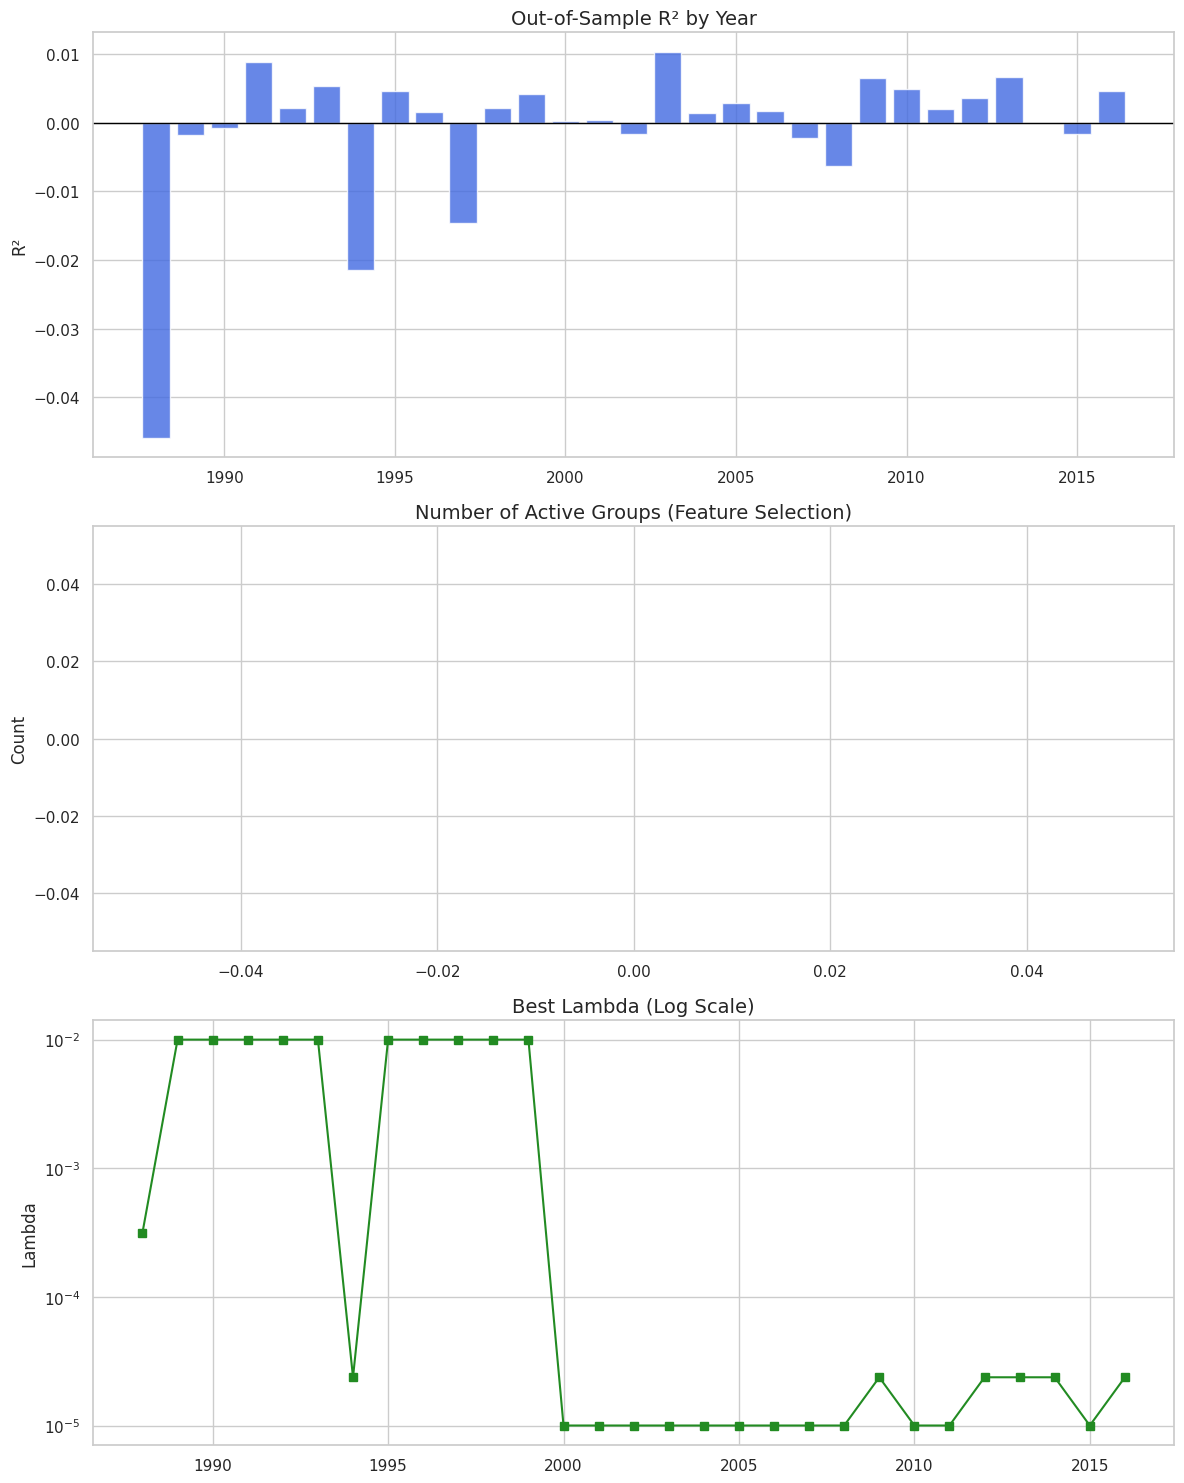

--- R² Statistics ---
count    29.000000
mean     -0.000782
std       0.010747
min      -0.045843
25%      -0.001650
50%       0.001655
75%       0.004544
max       0.010334
Name: test_r2, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# 图1: Out-of-Sample R2 (关键指标)
axes[0].bar(df_all_results['year'], df_all_results['test_r2'], color='royalblue', alpha=0.8)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Out-of-Sample R² by Year', fontsize=14)
axes[0].set_ylabel('R²')

# 图2: Active Groups (模型稀疏度)
# 看看模型有没有在某些年份退化成常数（Active Groups=0）
axes[1].plot(df_all_results['year'], df_all_results['active_groups'], marker='o', color='crimson')
axes[1].set_title('Number of Active Groups (Feature Selection)', fontsize=14)
axes[1].set_ylabel('Count')

# 图3: Best Lambda (正则化强度)
axes[2].plot(df_all_results['year'], df_all_results['best_lambda'], marker='s', color='forestgreen')
axes[2].set_yscale('log')
axes[2].set_title('Best Lambda (Log Scale)', fontsize=14)
axes[2].set_ylabel('Lambda')

plt.tight_layout()
plt.show()

# 打印描述性统计
print("--- R² Statistics ---")
print(df_all_results['test_r2'].describe())

In [12]:
import joblib
import os
import pandas as pd

# 路径确认（请根据你实际的 Drive 文件夹名修改）
save_dir = "/content/drive/MyDrive/GLM_Results"

summary_list = []

if os.path.exists(save_dir):
    # 获取所有 .pkl 文件并排序
    all_files = sorted([f for f in os.listdir(save_dir) if f.endswith('.pkl')])

    for file_name in all_files:
        path = os.path.join(save_dir, file_name)
        try:
            res = joblib.load(path)
            # 提取年份（假设文件名是 glm_res_1987.pkl）
            year_str = "".join(filter(str.isdigit, file_name))

            summary_list.append({
                'year': int(year_str),
                'test_r2': res.get('test_r2'),
                'active_groups': res.get('active_groups'),
                'best_lambda': res.get('best_lambda'),
                'converged': res.get('converged')
            })
        except Exception as e:
            print(f"读取 {file_name} 出错: {e}")

    # --- 关键：在这里定义 df_all_results ---
    if summary_list:
        df_all_results = pd.DataFrame(summary_list).sort_values('year')
        print(f"✅ 成功定义 df_all_results，包含 {len(df_all_results)} 年的数据。")
        print(df_all_results.head())
    else:
        print("❌ 未发现有效数据，请检查文件夹内容。")
else:
    print(f"❌ 找不到路径: {save_dir}")

✅ 成功定义 df_all_results，包含 29 年的数据。
   year   test_r2 active_groups  best_lambda converged
0  1988 -0.045843          None     0.000316      None
1  1989 -0.001868          None     0.010000      None
2  1990 -0.000786          None     0.010000      None
3  1991  0.008809          None     0.010000      None
4  1992  0.002186          None     0.010000      None


In [14]:
# 1. 检查 df_all_results 是否存在
if 'df_all_results' in locals():
    # 将 DataFrame 转换为漂亮的表格字符串
    report_text = df_all_results.to_string(index=False)

    # 保存为 txt
    with open('/content/drive/MyDrive/GLM_Results/summary_report.txt', 'w') as f:
        f.write("GLM Rolling Window Backtest Summary (1988-2016)\n")
        f.write("="*60 + "\n")
        f.write(report_text)

    print("✅ 汇总报告已生成：summary_report.txt")
else:
    print("❌ 请先确保运行了合并代码生成 df_all_results")

✅ 汇总报告已生成：summary_report.txt
